## Dataset review aplikasi DJPajak
Mengunakan data emotion classify

Preprocessing step 1
- lower case
- contraction
- remove number or convert number
- remove punctuation
- remove stopwords
- combine preprocessing method

Preprocessing step 2
- stemming
- lemmatization



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('djpajakappreview.csv')
df

,score,content
0,5,mantap
1,1,aplikasi tidak mutu masa baru buka sdh keluar ...
2,5,ok
3,1,Aplikasi SANGAT Pro
4,1,selalu gagal cek efrin
...,...,...
5023,5,Mudah bgt sekarang
5024,5,Waw keren
5025,5,"Mantab, ini yg resmi ya ?"
5026,5,Buat billing jadi lebih mudah 😍 semoga fitur f...


In [4]:
print(df.head(20).to_string()) #tampilkan 5 data teratas tanpa terpotong

    score                                                                                                                                                                                                                                                                                                                                                                                             content
0       5                                                                                                                                                                                                                                                                                                                                                                                              mantap
1       1                                                                                                                                                                                                   

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5028 entries, 0 to 5027
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   score    5028 non-null   int64 
 1   content  5028 non-null   object
dtypes: int64(1), object(1)
memory usage: 78.7+ KB


In [6]:
df.isna().sum()

score      0
content    0
dtype: int64

In [7]:
df['content'].value_counts()

content
Ok                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    92
Mantap                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [8]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Unduh resource
nltk.download('punkt')
nltk.download('stopwords')

# Stopwords Bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Kamus singkatan (bisa ditambah sesuai kebutuhan)
kamus_singkat = {
    'gmn': 'gimana',
    'udh': 'sudah',
    'tdk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'dr': 'dari',
    'yg': 'yang',
    'tp': 'tapi',
    'kl': 'kalau',
    'klo': 'kalau',
    'dgn': 'dengan',
    'aja': 'saja',
    'blm': 'belum',
    'ok': 'oke',
    'bgt': 'banget',
    'ilang': 'hilang',
    'korup': 'korupsi',
    'lemot': 'lambat',
    'nggak': 'tidak', 
    'efin': 'nama',
    'nya':  'imbuhan',
    'ya': 'iya',

}

# Fungsi normalisasi singkatan
def normalisasi_kata(kalimat):
    return ' '.join([kamus_singkat.get(kata, kata) for kata in kalimat.split()])

# Fungsi pembersih teks (Preprocessing Step 1)
def clean_text(text):
    if pd.isnull(text):
        return ""
    
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+|www\S+|@\S+", "", text)  # hapus URL & mention
    text = re.sub(r"\d+", "", text)  # hapus angka
    text = re.sub(r"[^\w\s]", "", text)  # hapus tanda baca
    text = normalisasi_kata(text)  # normalisasi singkatan
    words = word_tokenize(text)  # tokenisasi
    words = [w for w in words if w not in stop_words]  # hapus stopwords
    return " ".join(words)

# Terapkan ke kolom
df['clean_content'] = df['content'].apply(clean_text)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
#!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#Buat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

#Stemming
def stemming(text):
    return stemmer.stem(text)

#Terapkan stemming
df['stemmed_content'] = df['clean_content'].apply(stemming)



In [10]:
pd.options.display.max_colwidth = None

In [11]:
df["content"] = df["content"].apply(clean_text)
df.head(10)  #Periksa apakah sudah berubah

,score,content,clean_content,stemmed_content
0,5,mantap,mantap,mantap
1,1,aplikasi mutu buka sdh sendri,aplikasi mutu buka sdh sendri,aplikasi mutu buka sdh sendri
2,5,oke,oke,oke
3,1,aplikasi pro,aplikasi pro,aplikasi pro
4,1,gagal cek efrin,gagal cek efrin,gagal cek efrin
5,1,aplikasi sampah gunain,aplikasi sampah gunain,aplikasi sampah gunain
6,1,aplikasi berguna,aplikasi berguna,aplikasi guna
7,1,awas aplikasi phising,awas aplikasi phising,awas aplikasi phising
8,1,aplikasi ampas,aplikasi ampas,aplikasi ampas
9,1,trus gimana lupa password nomor hp imbuhan ganti lm udah hilang,trus gimana lupa password nomor hp imbuhan ganti lm udah hilang,trus gimana lupa password nomor hp imbuh ganti lm udah hilang


## Frekunsi Kata


In [12]:
def kamus(check):
    check = check.str.extractall(r'([a-zA-Z]+)')  #ambil kata aja (huruf)
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata': check.index, 'freq': check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis=1, inplace=True)
    kamus.sort_values('freq', ascending=False, inplace=True)

    return kamus

In [13]:
df_positif = df[df['score'].isin([4, 5])]
df_netral = df[df['score'] == 3]
df_negatif = df[df['score'].isin([1, 2])]


In [14]:
kamus_positif = kamus(df_positif['clean_content'])
kamus_netral = kamus(df_netral['clean_content'])
kamus_negatif = kamus(df_negatif['clean_content'])


<Figure size 1000x600 with 0 Axes>

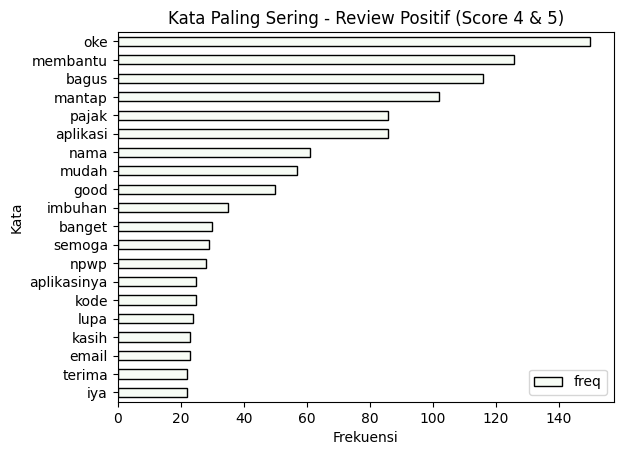

<Figure size 1000x600 with 0 Axes>

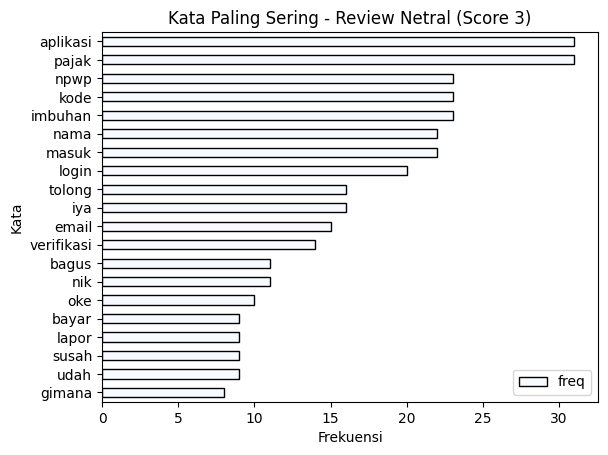

<Figure size 1000x600 with 0 Axes>

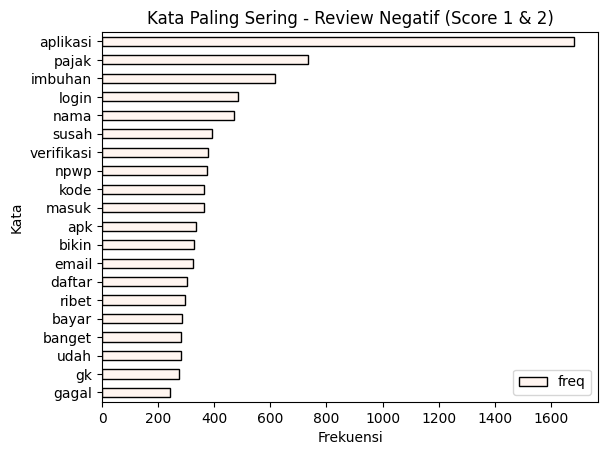

In [17]:
#POSITIF
plt.figure(figsize=(10, 6))
kamus_positif[:20].plot(kind='barh', colormap='Greens', edgecolor='black', legend=True)
plt.title("Kata Paling Sering - Review Positif (Score 4 & 5)")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.gca().invert_yaxis()
plt.show()

#NETRAL
plt.figure(figsize=(10, 6))
kamus_netral[:20].plot(kind='barh', colormap='Blues', edgecolor='black', legend=True)
plt.title("Kata Paling Sering - Review Netral (Score 3)")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.gca().invert_yaxis()
plt.show()

#NEGATIF
plt.figure(figsize=(10, 6))
kamus_negatif[:20].plot(kind='barh', colormap='Reds', edgecolor='black', legend=True)
plt.title("Kata Paling Sering - Review Negatif (Score 1 & 2)")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.gca().invert_yaxis()
plt.show()


## WordCloud

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#berdasarkan kategori skor
positif = df[df['score'].isin([4, 5])]['clean_content']
netral = df[df['score'] == 3]['clean_content']
negatif = df[df['score'].isin([1, 2])]['clean_content']

#Gabungkan teks jadi 1 string per kategori
text_positif = " ".join(positif)
text_netral = " ".join(netral)
text_negatif = " ".join(negatif)


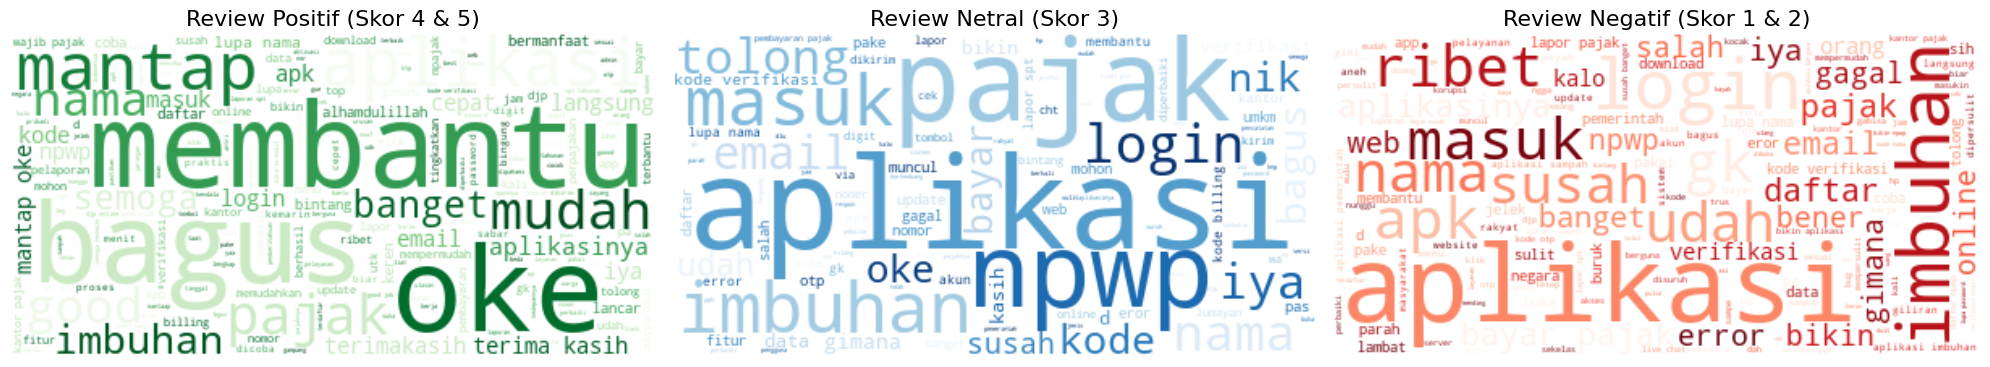

In [19]:
#Ukuran gambar
plt.figure(figsize=(20, 10))

#Wordcloud Positif
plt.subplot(1, 3, 1)
wordcloud_pos = WordCloud(background_color='white', colormap='Greens').generate(text_positif)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title("Review Positif (Skor 4 & 5)", fontsize=16)
plt.axis("off")

#Wordcloud Netral
plt.subplot(1, 3, 2)
wordcloud_netral = WordCloud(background_color='white', colormap='Blues').generate(text_netral)
plt.imshow(wordcloud_netral, interpolation='bilinear')
plt.title("Review Netral (Skor 3)", fontsize=16)
plt.axis("off")

#Wordcloud Negatif
plt.subplot(1, 3, 3)
wordcloud_neg = WordCloud(background_color='white', colormap='Reds').generate(text_negatif)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title("Review Negatif (Skor 1 & 2)", fontsize=16)
plt.axis("off")

plt.tight_layout()
plt.show()
